<a href="https://colab.research.google.com/github/YuliethRojas/TalentoTech/blob/Actividades/4_Notebook_An%C3%A1lisis_Componentes_Principales_(PCA).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mall-customers

In [ ]:
# Librerias necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import matplotlib.font_manager
from matplotlib import style
import warnings
warnings.filterwarnings('ignore')
from sklearn.decomposition import PCA

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install kaggle

# Sube tu archivo kaggle.json
from google.colab import files
files.upload()

# Crea un directorio y mueve kaggle.json
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Descargar el dataset
!kaggle datasets download -d unsdsn/Mall_Customers

# Descomprimir el dataset
# !unzip Mall_Customers.zip

# Leer el archivo CSV
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/BD Yulieth/Student_performance_data _.csv')

print(df.head())

Saving Student_performance_data _.csv to Student_performance_data _ (1).csv
mkdir: cannot create directory ‘/root/.kaggle’: File exists
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
403 - Forbidden - Permission 'datasets.get' was denied
   StudentID  Age  Gender  Ethnicity  ParentalEducation  StudyTimeWeekly  \
0       1001   17       1          0                  2        19.833723   
1       1002   18       0          0                  1        15.408756   
2       1003   15       0          2                  3         4.210570   
3       1004   17       1          0                  3        10.028829   
4       1005   17       1          0                  2         4.672495   

   Absences  Tutoring  ParentalSupport  Extracurricular  Sports  Music  \
0         7         1                2                0       0      1   
1         0         0                1                0       0      0 

In [ ]:
df

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2387,3388,18,1,0,3,10.680555,2,0,4,1,0,0,0,3.455509,0.0
2388,3389,17,0,0,1,7.583217,4,1,4,0,1,0,0,3.279150,4.0
2389,3390,16,1,0,2,6.805500,20,0,2,0,0,0,1,1.142333,2.0
2390,3391,16,1,1,0,12.416653,17,0,2,0,1,1,0,1.803297,1.0


In [ ]:
# Eliminar la columna 'Overall rank'
# df = df.drop('Overall rank', axis=1)

# Imprimir las primeras 5 filas del DataFrame (sin la columna eliminada)
print(df.head())

   StudentID  Age  Gender  Ethnicity  ParentalEducation  StudyTimeWeekly  \
0       1001   17       1          0                  2        19.833723   
1       1002   18       0          0                  1        15.408756   
2       1003   15       0          2                  3         4.210570   
3       1004   17       1          0                  3        10.028829   
4       1005   17       1          0                  2         4.672495   

   Absences  Tutoring  ParentalSupport  Extracurricular  Sports  Music  \
0         7         1                2                0       0      1   
1         0         0                1                0       0      0   
2        26         0                2                0       0      0   
3        14         0                3                1       0      0   
4        17         1                3                0       0      0   

   Volunteering       GPA  GradeClass  
0             0  2.929196         2.0  
1             0  3

         StudentID          Age       Gender    Ethnicity  ParentalEducation  \
count  2392.000000  2392.000000  2392.000000  2392.000000        2392.000000   
mean   2196.500000    16.468645     0.510870     0.877508           1.746237   
std     690.655244     1.123798     0.499986     1.028476           1.000411   
min    1001.000000    15.000000     0.000000     0.000000           0.000000   
25%    1598.750000    15.000000     0.000000     0.000000           1.000000   
50%    2196.500000    16.000000     1.000000     0.000000           2.000000   
75%    2794.250000    17.000000     1.000000     2.000000           2.000000   
max    3392.000000    18.000000     1.000000     3.000000           4.000000   

       StudyTimeWeekly     Absences     Tutoring  ParentalSupport  \
count      2392.000000  2392.000000  2392.000000      2392.000000   
mean          9.771992    14.541388     0.301421         2.122074   
std           5.652774     8.467417     0.458971         1.122813   
min

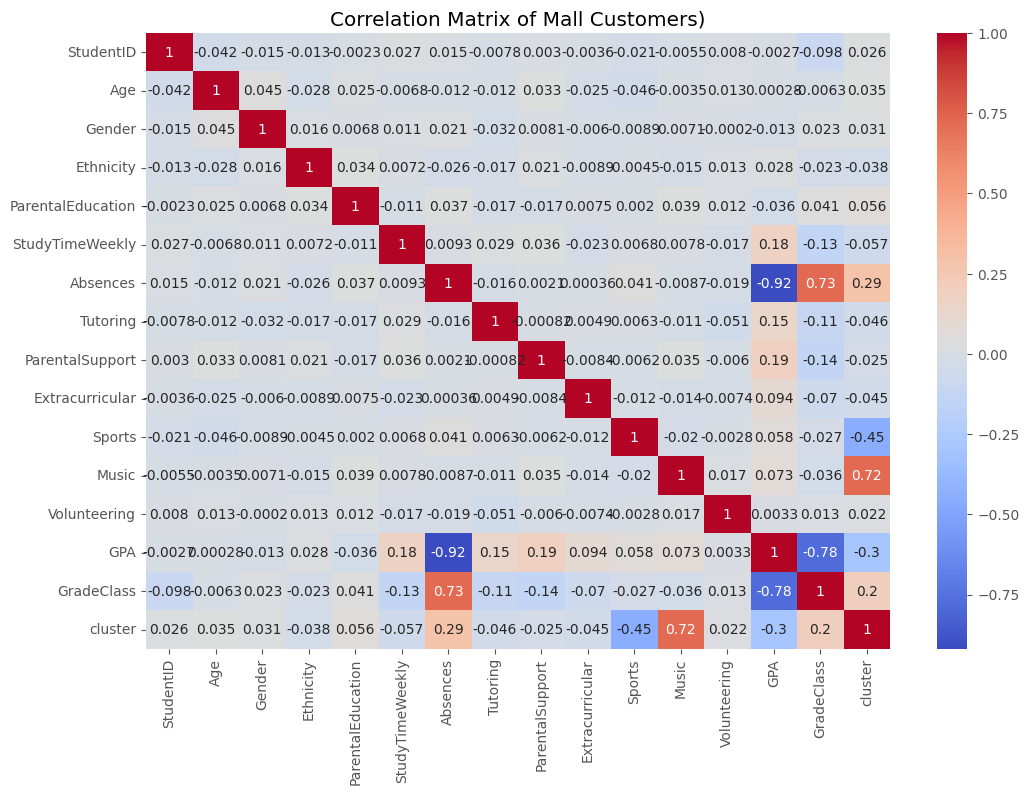

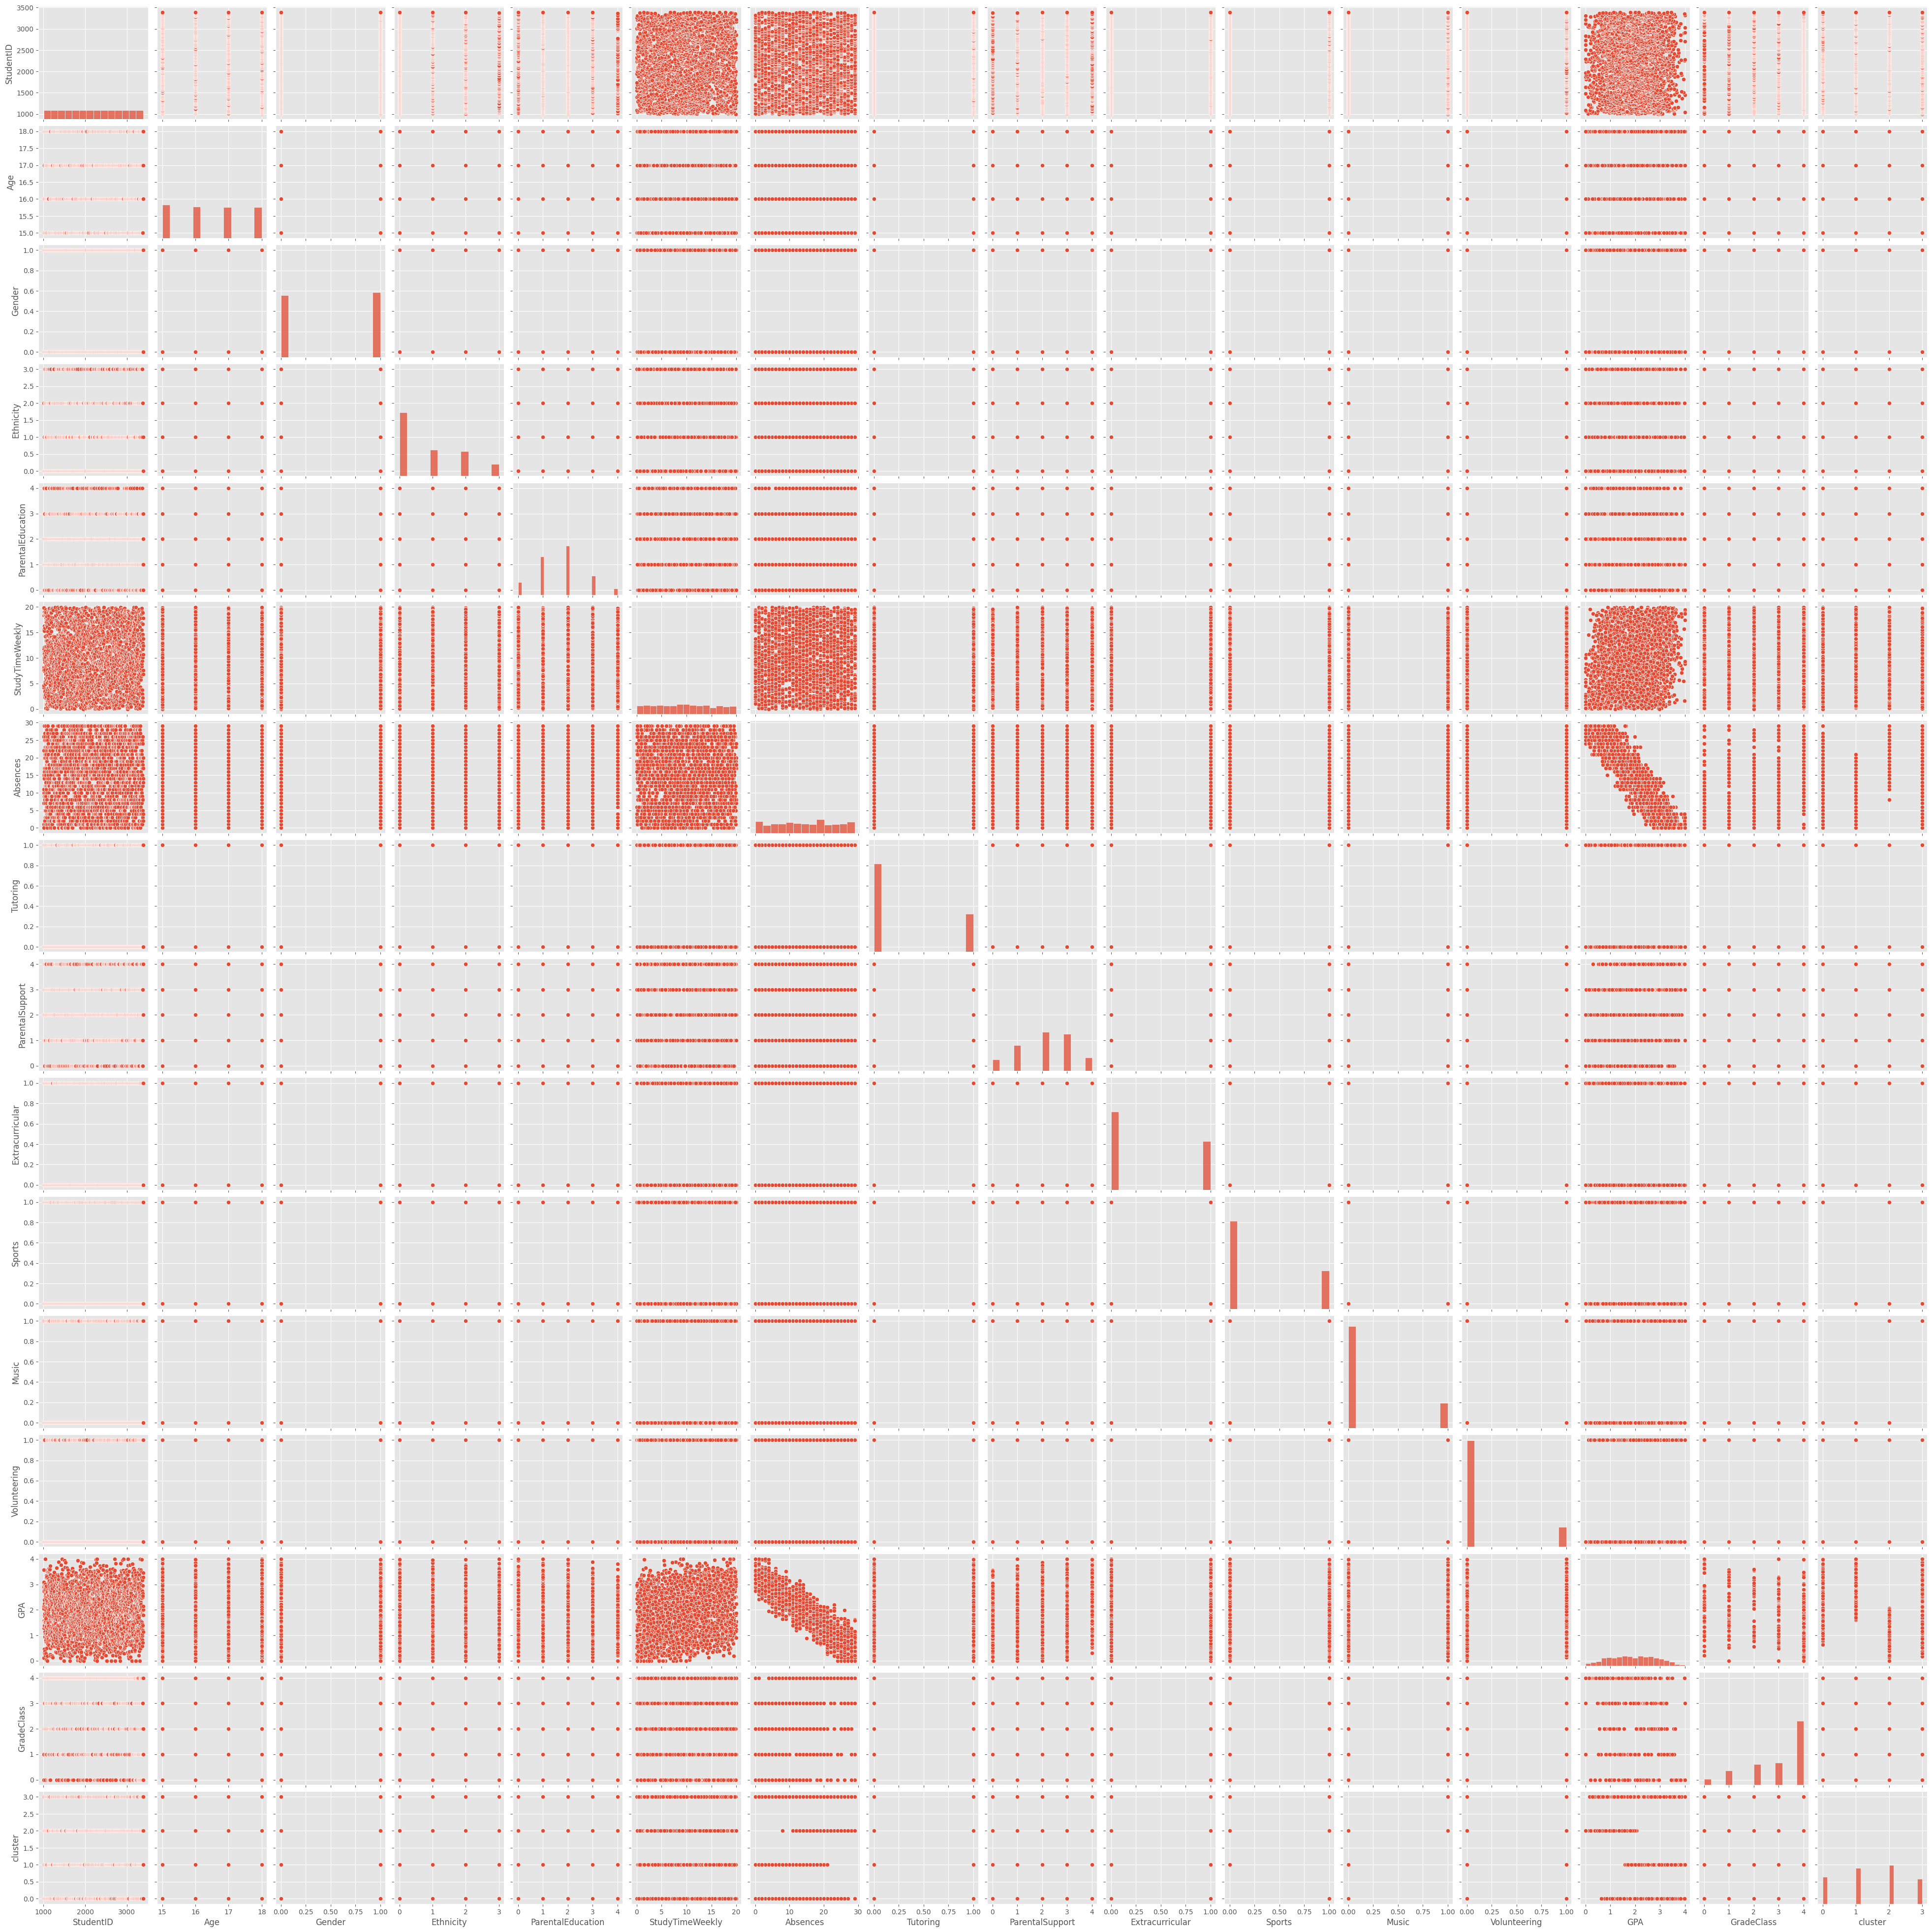

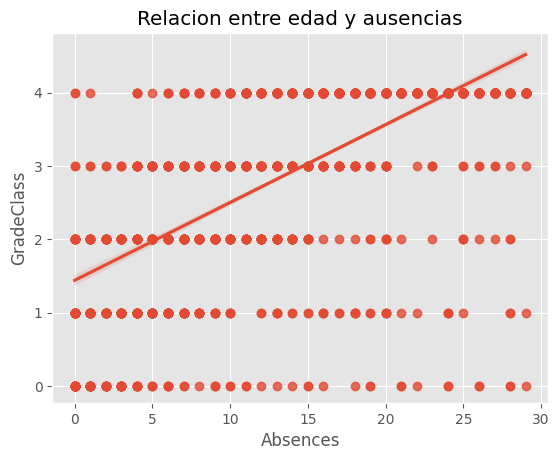

In [ ]:
# Seleccionar sólo columnas numéricas para el análisis de correlación
numeric_df = df.select_dtypes(include=np.number)

# Estadísticas descriptivas para características numéricas
print(numeric_df.describe())

# Matriz de correlación para características numéricas
correlation_matrix = numeric_df.corr()
print(correlation_matrix)

# Mapa de calor de la matriz de correlación
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Mall Customers)')
plt.show()

# Pairplot para visualizar relaciones entre variables numéricas
sns.pairplot(numeric_df)
plt.show()

# Análisis de regresión
sns.regplot(x='Absences', y='GradeClass', data=df)  # Usando df original para contexto
plt.title('Relacion entre edad y ausencias')
plt.show()

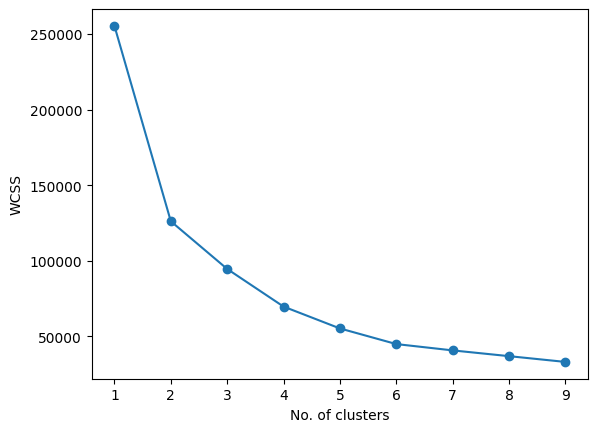

wcss: [255409.07300213812, 126188.08874947921, 94639.47629092424, 69745.39846753397, 55294.572753010034, 44948.737860162226, 40770.54424128376, 36960.007540378756, 33142.65499529471]


In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt


wcss = []


numeric_df = df.drop(['StudentID', 'Gender', 'Ethnicity', 'ParentalEducation', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GradeClass'], axis=1)


for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, random_state=3)
    kmeans.fit(numeric_df)  # Fit the model on the numeric data
    wcss.append(kmeans.inertia_)  # Append the within-cluster sum of squares (WCSS) for each cluster count


plt.plot(range(1, 10), wcss, '-o')
plt.xlabel('No. of clusters')
plt.ylabel('WCSS')
plt.show()

print('wcss: ' + str(wcss))

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Seleccionar las columnas relevantes para el clustering
X = df[['Age','Gender','Ethnicity','ParentalEducation','StudyTimeWeekly','Absences','Tutoring','ParentalSupport','Extracurricular','Sports','Music','Volunteering','GPA']]

# Escalar los datos para que todas las variables tengan la misma importancia
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elegir el número de clusters (puedes ajustar este valor)
n_clusters = 4   #Técnica de codo, método de la  silueta.

# Crear el modelo KMeans
kmeans = KMeans(n_clusters=n_clusters, random_state=42)

# Entrenar el modelo con los datos escalados
kmeans.fit(X_scaled)

# Asignar las etiquetas de cluster a los datos
datosorginal=df
df['cluster'] = kmeans.labels_

# Calculate the mean for only numeric columns
numeric_cols = df.select_dtypes(include=np.number).columns
cluster_means = df.groupby('cluster')[numeric_cols].mean()  # Select numeric columns for mean calculation

# Mostrar los resultados
print(cluster_means)

           StudentID        Age    Gender  Ethnicity  ParentalEducation  \
cluster                                                                   
0        2153.697266  16.361328  0.492188   0.914062           1.710938   
1        2193.381443  16.486009  0.488954   0.941090           1.652430   
2        2231.381992  16.529332  0.538881   0.814461           1.803547   
3        2193.217949  16.465812  0.519231   0.844017           1.831197   

         StudyTimeWeekly   Absences  Tutoring  ParentalSupport  \
cluster                                                          
0              10.222037  13.222656  0.335938         2.173828   
1              10.366260   7.402062  0.319588         2.203240   
2               8.819173  22.225102  0.266030         1.956344   
3               9.909781  14.307692  0.292735         2.207265   

         Extracurricular    Sports     Music  Volunteering       GPA  \
cluster                                                                
0       

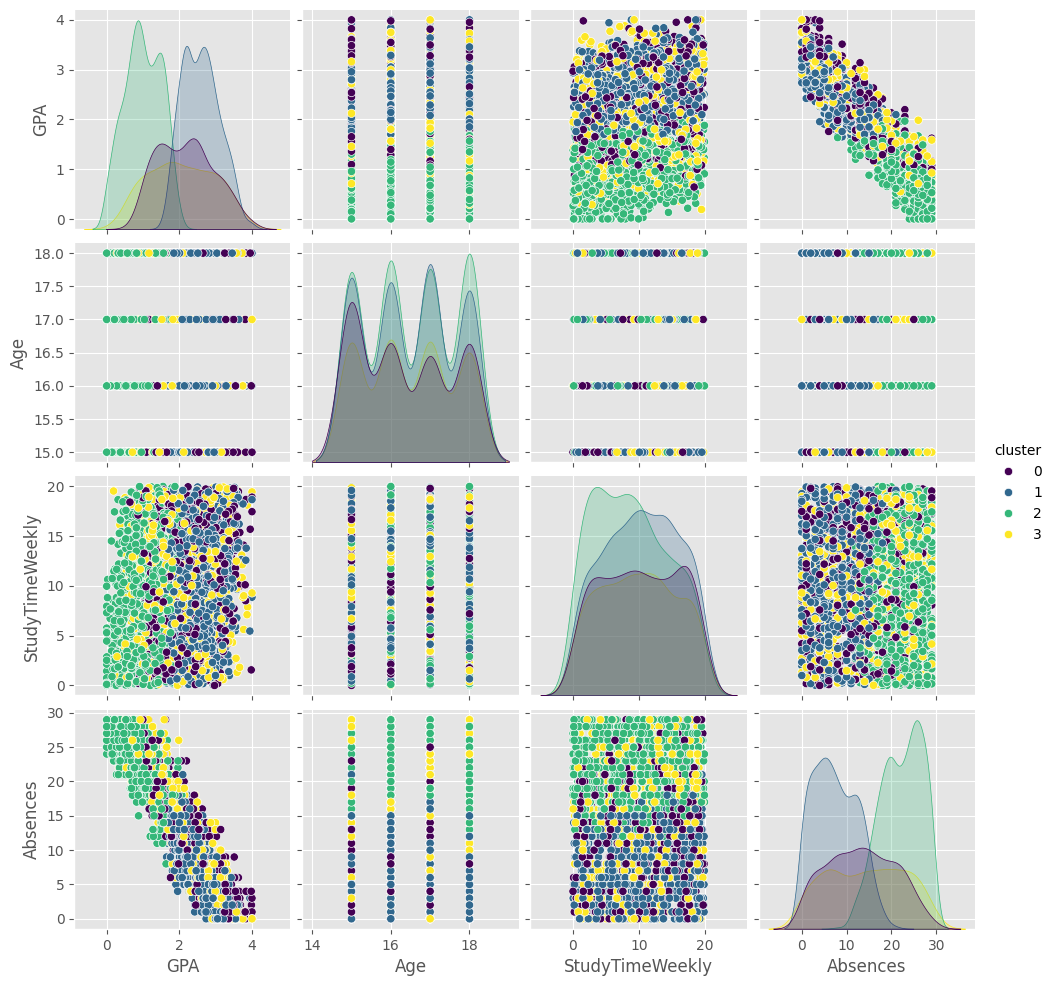

In [ ]:
sns.pairplot(df, hue='cluster', vars=['GPA', 'Age', 'StudyTimeWeekly', 'Absences'], palette='viridis')
plt.show()


Análisis del Cluster 0:

Estadísticas Descriptivas:
         StudentID         Age      Gender   Ethnicity  ParentalEducation  \
count   512.000000  512.000000  512.000000  512.000000         512.000000   
mean   2153.697266   16.361328    0.492188    0.914062           1.710938   
std     702.021579    1.160466    0.500428    1.026287           0.994327   
min    1007.000000   15.000000    0.000000    0.000000           0.000000   
25%    1554.500000   15.000000    0.000000    0.000000           1.000000   
50%    2121.500000   16.000000    0.000000    1.000000           2.000000   
75%    2793.250000   17.000000    1.000000    2.000000           2.000000   
max    3389.000000   18.000000    1.000000    3.000000           4.000000   

       StudyTimeWeekly    Absences    Tutoring  ParentalSupport  \
count       512.000000  512.000000  512.000000       512.000000   
mean         10.222037   13.222656    0.335938         2.173828   
std           5.771776    7.421687    0.472779      

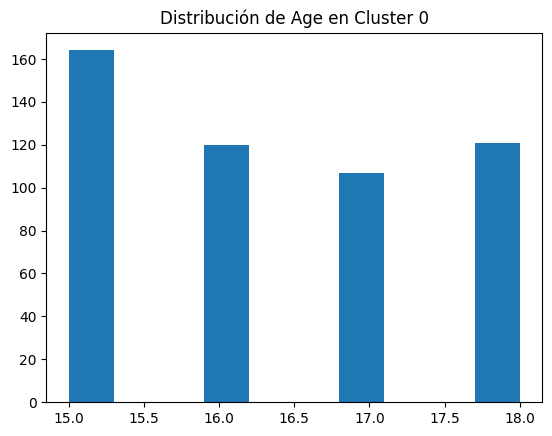


Variable: StudyTimeWeekly
count    512.000000
mean      10.222037
std        5.771776
min        0.001057
25%        5.314786
50%       10.188489
75%       15.669114
max       19.939810
Name: StudyTimeWeekly, dtype: float64


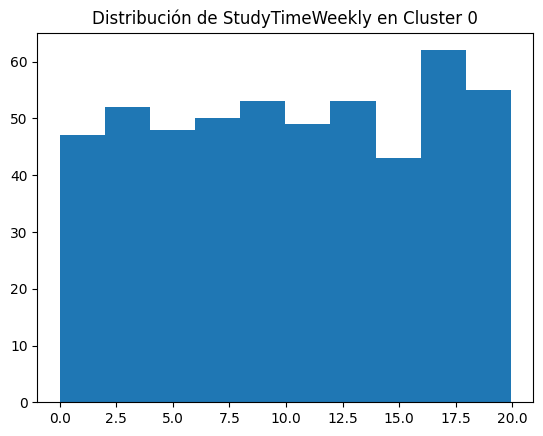


Variable: ParentalSupport
count    512.000000
mean       2.173828
std        1.132624
min        0.000000
25%        1.000000
50%        2.000000
75%        3.000000
max        4.000000
Name: ParentalSupport, dtype: float64


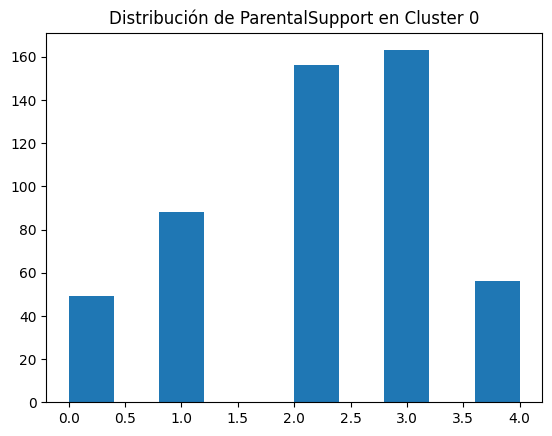


Países en el Cluster:
Gender
0    260
1    252
Name: count, dtype: int64

Análisis del Cluster 1:

Estadísticas Descriptivas:
         StudentID         Age      Gender   Ethnicity  ParentalEducation  \
count   679.000000  679.000000  679.000000  679.000000         679.000000   
mean   2193.381443   16.486009    0.488954    0.941090           1.652430   
std     703.105549    1.106175    0.500246    1.050104           0.968511   
min    1002.000000   15.000000    0.000000    0.000000           0.000000   
25%    1567.500000   15.000000    0.000000    0.000000           1.000000   
50%    2173.000000   17.000000    0.000000    1.000000           2.000000   
75%    2808.500000   17.000000    1.000000    2.000000           2.000000   
max    3392.000000   18.000000    1.000000    3.000000           4.000000   

       StudyTimeWeekly    Absences    Tutoring  ParentalSupport  \
count       679.000000  679.000000  679.000000       679.000000   
mean         10.366260    7.402062    0.31958

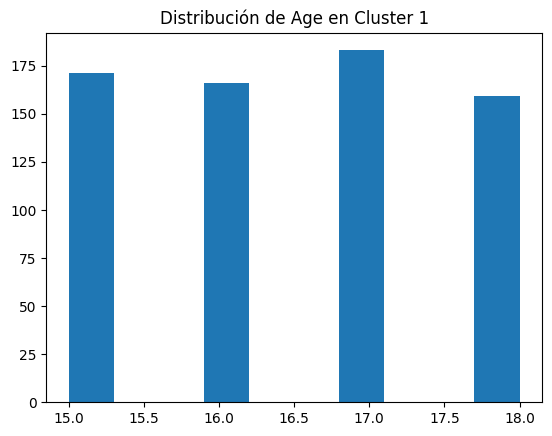


Variable: StudyTimeWeekly
count    679.000000
mean      10.366260
std        5.531066
min        0.025689
25%        5.906840
50%       10.416312
75%       14.824177
max       19.948459
Name: StudyTimeWeekly, dtype: float64


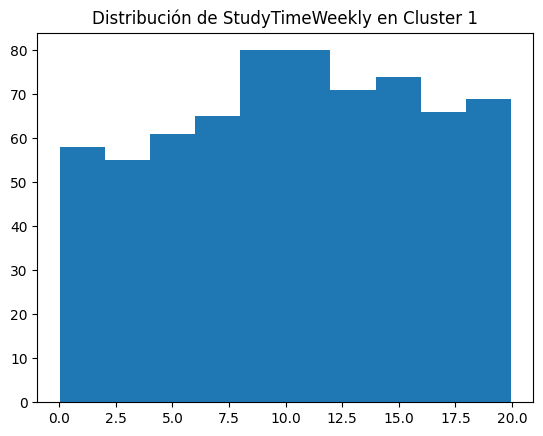


Variable: ParentalSupport
count    679.000000
mean       2.203240
std        1.110391
min        0.000000
25%        1.000000
50%        2.000000
75%        3.000000
max        4.000000
Name: ParentalSupport, dtype: float64


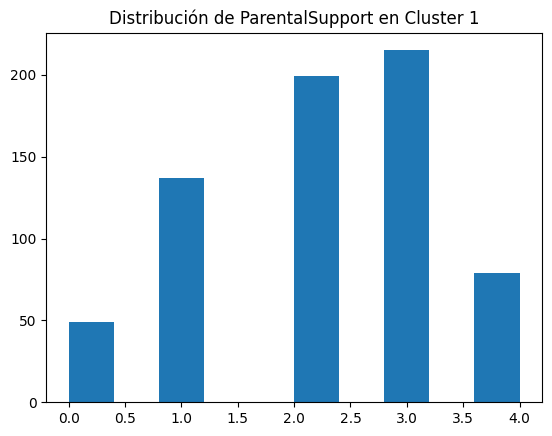


Países en el Cluster:
Gender
0    347
1    332
Name: count, dtype: int64

Análisis del Cluster 2:

Estadísticas Descriptivas:
         StudentID         Age      Gender   Ethnicity  ParentalEducation  \
count   733.000000  733.000000  733.000000  733.000000         733.000000   
mean   2231.381992   16.529332    0.538881    0.814461           1.803547   
std     679.542532    1.121462    0.498826    1.012738           1.021431   
min    1003.000000   15.000000    0.000000    0.000000           0.000000   
25%    1650.000000   16.000000    0.000000    0.000000           1.000000   
50%    2268.000000   17.000000    1.000000    0.000000           2.000000   
75%    2801.000000   18.000000    1.000000    2.000000           2.000000   
max    3390.000000   18.000000    1.000000    3.000000           4.000000   

       StudyTimeWeekly    Absences    Tutoring  ParentalSupport  \
count       733.000000  733.000000  733.000000       733.000000   
mean          8.819173   22.225102    0.26603

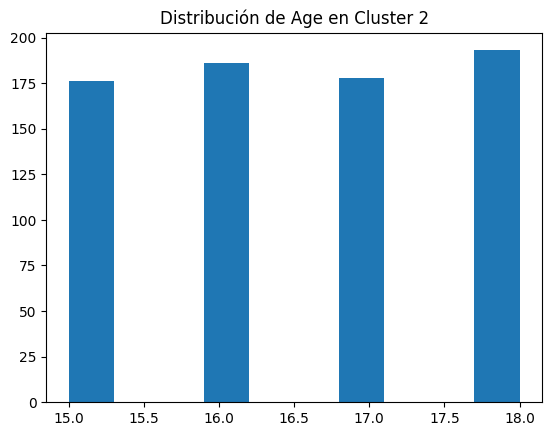


Variable: StudyTimeWeekly
count    733.000000
mean       8.819173
std        5.556679
min        0.004859
25%        4.070710
50%        8.362632
75%       13.348311
max       19.978094
Name: StudyTimeWeekly, dtype: float64


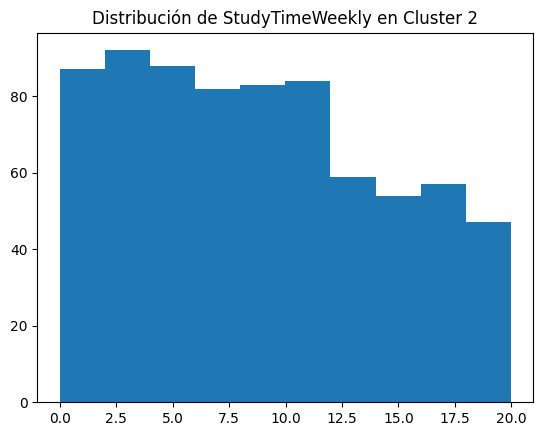


Variable: ParentalSupport
count    733.000000
mean       1.956344
std        1.117791
min        0.000000
25%        1.000000
50%        2.000000
75%        3.000000
max        4.000000
Name: ParentalSupport, dtype: float64


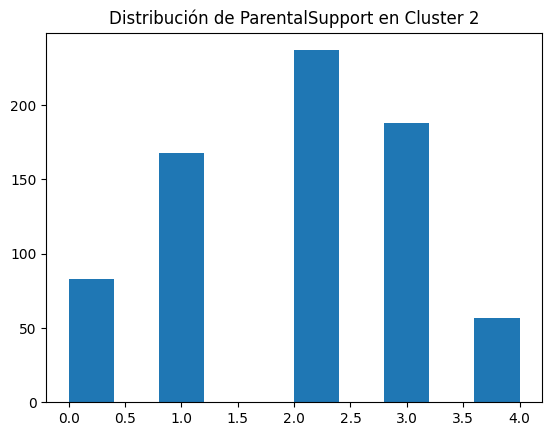


Países en el Cluster:
Gender
1    395
0    338
Name: count, dtype: int64

Análisis del Cluster 3:

Estadísticas Descriptivas:
         StudentID         Age      Gender   Ethnicity  ParentalEducation  \
count   468.000000  468.000000  468.000000  468.000000         468.000000   
mean   2193.217949   16.465812    0.519231    0.844017           1.831197   
std     676.371513    1.107163    0.500165    1.019734           1.009234   
min    1001.000000   15.000000    0.000000    0.000000           0.000000   
25%    1614.750000   15.000000    0.000000    0.000000           1.000000   
50%    2179.000000   16.000000    1.000000    0.000000           2.000000   
75%    2760.000000   17.000000    1.000000    2.000000           2.000000   
max    3391.000000   18.000000    1.000000    3.000000           4.000000   

       StudyTimeWeekly    Absences    Tutoring  ParentalSupport  \
count       468.000000  468.000000  468.000000       468.000000   
mean          9.909781   14.307692    0.29273

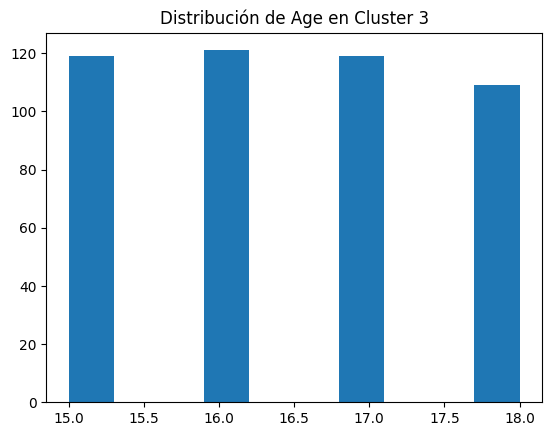


Variable: StudyTimeWeekly
count    468.000000
mean       9.909781
std        5.670675
min        0.018117
25%        5.069397
50%        9.898113
75%       14.444900
max       19.912084
Name: StudyTimeWeekly, dtype: float64


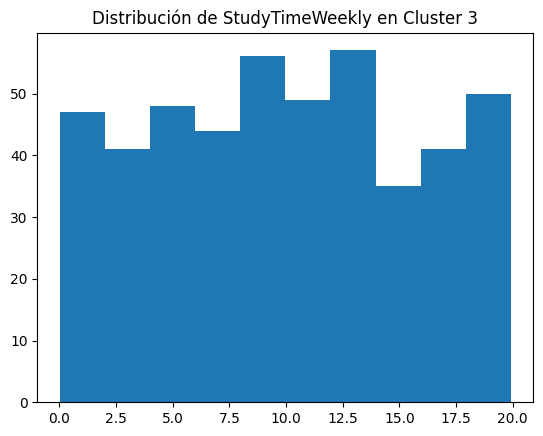


Variable: ParentalSupport
count    468.000000
mean       2.207265
std        1.113375
min        0.000000
25%        1.000000
50%        2.000000
75%        3.000000
max        4.000000
Name: ParentalSupport, dtype: float64


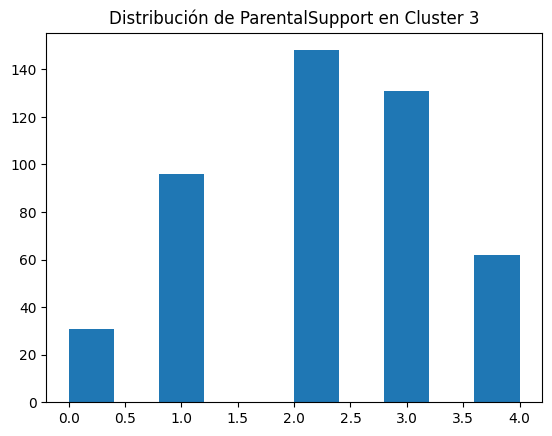


Países en el Cluster:
Gender
1    243
0    225
Name: count, dtype: int64


In [ ]:
# Analizar cada cluster por separado
for cluster_num in range(n_clusters):
  print(f"\nAnálisis del Cluster {cluster_num}:")
  cluster_data = df[df['cluster'] == cluster_num]

  # Estadísticas descriptivas para variables numéricas
  print("\nEstadísticas Descriptivas:")
  print(cluster_data.describe())

  # Distribución de variables clave (ejemplo: GDP per capita, Social support)
  print("\nDistribución de Variables Clave:")
  for col in ['Age', 'StudyTimeWeekly', 'ParentalSupport']:
    print(f"\nVariable: {col}")
    print(cluster_data[col].describe())
    # Puedes agregar un histograma para visualizar la distribución
    plt.hist(cluster_data[col], bins=10)
    plt.title(f"Distribución de {col} en Cluster {cluster_num}")
    plt.show()

  # Analizar la distribución de género en cada cluster
  print("\nPaíses en el Cluster:")
  print(cluster_data['Gender'].value_counts())

##Análisis de componentes principales
El análisis de componentes principales (Principal Component Analysis PCA) es un método de reducción de dimensionalidad que permite simplificar la complejidad de espacios con múltiples dimensiones a la vez que conserva su información.

In [ ]:
# Gráficos
style.use('ggplot') or plt.style.use('ggplot')

# Preprocesado y modelado
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import scale

In [ ]:
# Entrenamiento modelo PCA con escalado de los datos
# Select only numeric features for PCA
numeric_features = df.select_dtypes(include=np.number).columns
X_numeric = df[numeric_features]

pca_pipe = make_pipeline(StandardScaler(), PCA())
pca_pipe.fit(X_numeric)  # Fit on numeric data only

# Se extrae el modelo entrenado del pipeline
modelo_pca = pca_pipe.named_steps['pca']

In [ ]:
# Se convierte el array a dataframe para añadir nombres a los ejes.
num_pcs = modelo_pca.n_components_ # Get the actual number of components
pd.DataFrame(
    data    = modelo_pca.components_,
    columns = X_numeric.columns, # Use columns for numeric data only
    index   = [f'PC{i+1}' for i in range(num_pcs)] # Dynamically create index
)

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass,cluster
PC1,0.018656,-0.004508,-0.023306,0.028362,-0.045800,0.102435,-0.532352,0.090922,0.100723,0.054019,0.087225,-0.082641,-0.005844,0.564417,-0.510269,-0.295892
PC2,0.042995,0.055753,0.025623,-0.020623,0.050273,0.026991,-0.146049,0.005668,0.082815,-0.009852,-0.369505,0.614893,0.033962,0.163660,-0.175443,0.623732
PC3,-0.321050,0.483439,0.393329,0.239822,0.241588,-0.203732,-0.127862,-0.427052,0.087256,-0.102618,-0.059109,-0.084211,0.346657,0.020144,0.029578,-0.047072
PC4,-0.064576,0.303786,0.303428,-0.035170,-0.107696,0.524777,0.197615,0.205412,0.489185,-0.323896,0.083463,0.009664,-0.300290,0.004068,0.016830,-0.016085
PC5,0.379918,-0.408644,-0.004939,0.464037,0.239381,0.303221,0.087343,-0.286202,0.173133,-0.162037,0.272550,0.143683,0.287818,-0.003684,-0.020614,-0.009714
PC6,0.565676,0.137843,0.050951,-0.258879,-0.443109,0.068872,-0.037343,-0.283025,0.020895,-0.168460,-0.368828,-0.264526,0.262830,-0.053117,-0.044211,-0.011369
PC7,0.228294,-0.019968,0.278660,0.396691,0.196932,0.083094,0.052254,0.052805,0.022654,0.517769,-0.449167,-0.265199,-0.345627,-0.023400,-0.023994,-0.001265
PC8,0.102401,0.025923,0.197544,-0.481528,0.054778,0.034602,0.126073,-0.231759,0.296301,0.637775,0.329814,0.161105,0.117686,0.024828,-0.011121,-0.016453
PC9,0.337083,0.311013,-0.018690,-0.310043,0.671662,0.201348,-0.016961,0.183381,-0.374782,-0.139534,0.045692,-0.044474,0.034854,-0.004999,-0.042569,-0.023098
PC10,-0.040670,-0.268020,0.682406,-0.080998,-0.207110,0.126142,-0.095990,-0.100391,-0.550047,-0.092641,0.157508,0.128663,-0.150411,0.018459,-0.012462,0.023600


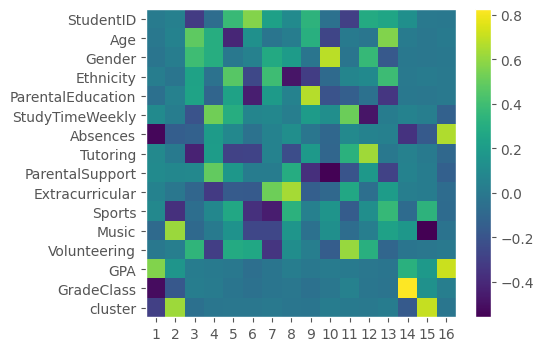

In [ ]:
# Heatmap componentes
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5, 4))
componentes = modelo_pca.components_
plt.imshow(componentes.T, cmap='viridis', aspect='auto')
plt.yticks(range(len(X_numeric.columns)), X_numeric.columns) # Use numeric columns
plt.xticks(range(modelo_pca.n_components_), np.arange(modelo_pca.n_components_) + 1) # Match ticks and labels
plt.grid(False)
plt.colorbar();

----------------------------------------------------
Porcentaje de varianza explicada por cada componente
----------------------------------------------------
[0.17697727 0.11169441 0.06892377 0.06706579 0.06599575 0.06442223
 0.06313986 0.06200542 0.06174136 0.06105933 0.059396   0.05793527
 0.05454582 0.01811234 0.00556442 0.00142094]


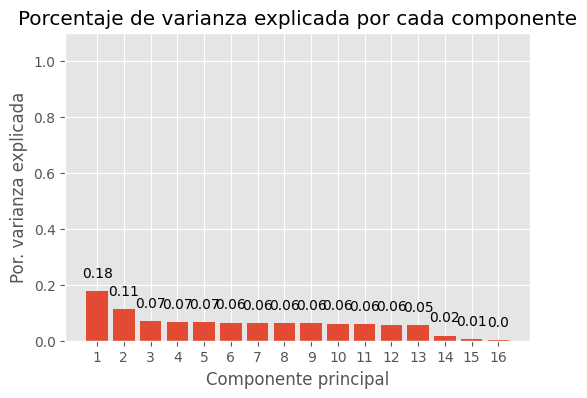

In [ ]:
# Porcentaje de varianza explicada por cada componente
print('----------------------------------------------------')
print('Porcentaje de varianza explicada por cada componente')
print('----------------------------------------------------')
print(modelo_pca.explained_variance_ratio_)

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 4))
ax.bar(
    x      = np.arange(modelo_pca.n_components_) + 1,
    height = modelo_pca.explained_variance_ratio_
)

for x, y in zip(np.arange(len(df.columns)) + 1, modelo_pca.explained_variance_ratio_):
    label = round(y, 2)
    ax.annotate(
        label,
        (x,y),
        textcoords="offset points",
        xytext=(0,10),
        ha='center'
    )

ax.set_xticks(np.arange(modelo_pca.n_components_) + 1)
ax.set_ylim(0, 1.1)
ax.set_title('Porcentaje de varianza explicada por cada componente')
ax.set_xlabel('Componente principal')
ax.set_ylabel('Por. varianza explicada');

------------------------------------------
Porcentaje de varianza explicada acumulada
------------------------------------------
[0.17697727 0.28867168 0.35759545 0.42466124 0.49065699 0.55507923
 0.61821909 0.68022451 0.74196587 0.8030252  0.8624212  0.92035647
 0.97490229 0.99301463 0.99857906 1.        ]


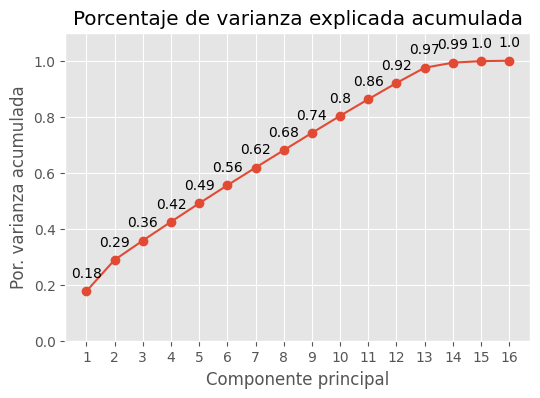

In [ ]:
# Porcentaje de varianza explicada acumulada
prop_varianza_acum = modelo_pca.explained_variance_ratio_.cumsum()
print('------------------------------------------')
print('Porcentaje de varianza explicada acumulada')
print('------------------------------------------')
print(prop_varianza_acum)

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 4))
ax.plot(
    np.arange(modelo_pca.n_components_) + 1, # Changed to match number of components
    prop_varianza_acum,
    marker = 'o'
)

for x, y in zip(np.arange(modelo_pca.n_components_) + 1, prop_varianza_acum): # Changed loop range
    label = round(y, 2)
    ax.annotate(
        label,
        (x,y),
        textcoords="offset points",
        xytext=(0,10),
        ha='center'
    )

ax.set_ylim(0, 1.1)
ax.set_xticks(np.arange(modelo_pca.n_components_) + 1)
ax.set_title('Porcentaje de varianza explicada acumulada')
ax.set_xlabel('Componente principal')
ax.set_ylabel('Por. varianza acumulada');

## Modelo

In [ ]:
# Gráficos
from matplotlib import style
style.use('ggplot') or plt.style.use('ggplot')

# Preprocesado y modelado
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import multiprocessing


In [ ]:
# Correlación entre columnas numéricas

def tidy_corr_matrix(corr_mat):
    '''
    Función para convertir una matriz de correlación de pandas en formato tidy
    '''
    corr_mat = corr_mat.stack().reset_index()
    corr_mat.columns = ['variable_1','variable_2','r']
    corr_mat = corr_mat.loc[corr_mat['variable_1'] != corr_mat['variable_2'], :]
    corr_mat['abs_r'] = np.abs(corr_mat['r'])
    corr_mat = corr_mat.sort_values('abs_r', ascending=False)

    return(corr_mat)

corr_matrix = df.select_dtypes(include=['float64', 'int']) \
              .corr(method='pearson')
display(tidy_corr_matrix(corr_matrix).head(5))

,variable_1,variable_2,r,abs_r
109,Absences,GPA,-0.919314,0.919314
214,GPA,Absences,-0.919314,0.919314
222,GPA,GradeClass,-0.782835,0.782835
237,GradeClass,GPA,-0.782835,0.782835
110,Absences,GradeClass,0.728633,0.728633


In [ ]:
# División de los datos en train y test
X = df.drop(columns='GradeClass')
y = df['GradeClass']

X_train, X_test, y_train, y_test = train_test_split(
                                        X,
                                        y.values.reshape(-1,1),
                                        train_size   = 0.7,
                                        random_state = 1234,
                                        shuffle      = True
                                    )

In [ ]:
# División de los datos en train y test
# Select only numerical features for the model
numerical_features = df.select_dtypes(include=['float64', 'int']).columns
X = df[numerical_features].drop(columns='GradeClass')
y = df['GradeClass']

X_train, X_test, y_train, y_test = train_test_split(
                                        X,
                                        y.values.reshape(-1,1),
                                        train_size   = 0.7,
                                        random_state = 1234,
                                        shuffle      = True
                                    )

# Creación y entrenamiento del modelo
modelo = LinearRegression()
modelo.fit(X = X_train, y = y_train)

LinearRegression()

In [ ]:
# Predicciones test
predicciones = modelo.predict(X=X_test)
predicciones = predicciones.flatten()

# Error de test del modelo
rmse_ols = mean_squared_error(
            y_true  = y_test,
            y_pred  = predicciones,
            squared = False
           )
print("")
print(f"El error (rmse) de test es: {rmse_ols}")


El error (rmse) de test es: 0.7824898170937262



## Con PCA

In [ ]:
# Entrenamiento modelo de regresión precedido por PCA con escalado
pipe_modelado = make_pipeline(StandardScaler(), PCA(), LinearRegression())
pipe_modelado.fit(X=X_train, y=y_train)

Pipeline(steps=[('standardscaler', StandardScaler()), ('pca', PCA()),
                ('linearregression', LinearRegression())])

In [ ]:
pipe_modelado.set_params

<bound method Pipeline.set_params of Pipeline(steps=[('standardscaler', StandardScaler()), ('pca', PCA()),
                ('linearregression', LinearRegression())])>

In [ ]:
# Predicciones test
predicciones = pipe_modelado.predict(X=X_test)
predicciones = predicciones.flatten()

# Error de test del modelo
rmse_pcr = mean_squared_error(
            y_true  = y_test,
            y_pred  = predicciones,
            squared = False
           )
print("")
print(f"El error (rmse) de test es: {rmse_pcr}")


El error (rmse) de test es: 0.7824898170937277


In [ ]:
# Grid de hiperparámetros evaluados
param_grid = {'pca__n_components': [1, 2, 4, 5, 6]}

# Búsqueda por grid search con validación cruzada
grid = GridSearchCV(
        estimator  = pipe_modelado,
        param_grid = param_grid,
        scoring    = 'neg_root_mean_squared_error',
        n_jobs     = multiprocessing.cpu_count() - 1,
        cv         = KFold(n_splits=5, shuffle=True, random_state=123), # Added shuffle=True
        refit      = True,
        verbose    = 0,
        return_train_score = True
       )

grid.fit(X = X_train, y = y_train)

# Resultados
resultados = pd.DataFrame(grid.cv_results_)
resultados.filter(regex = '(param.*|mean_t|std_t)') \
    .drop(columns = 'params') \
    .sort_values('mean_test_score', ascending = False) \
    .head(3)

,param_pca__n_components,mean_test_score,std_test_score,mean_train_score,std_train_score
2,4,-0.768273,0.038231,-0.768062,0.011424
3,5,-0.768582,0.038234,-0.767086,0.011211
4,6,-0.768590,0.037716,-0.766384,0.011081


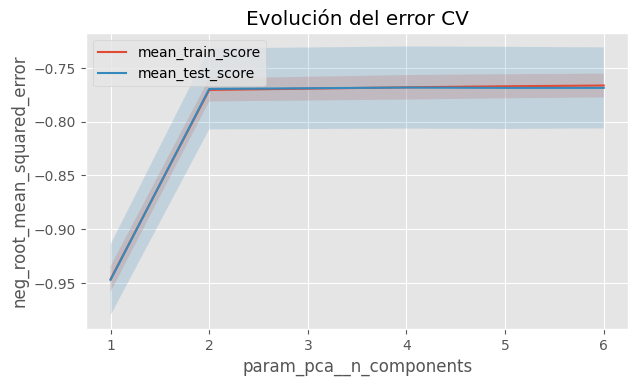

In [ ]:
# Gráfico resultados validación cruzada para cada hiperparámetro
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(7, 3.84), sharey=True)

resultados.plot('param_pca__n_components', 'mean_train_score', ax=ax)
resultados.plot('param_pca__n_components', 'mean_test_score', ax=ax)
ax.fill_between(resultados.param_pca__n_components.astype(float), # Changed np.float to float
                resultados['mean_train_score'] + resultados['std_train_score'],
                resultados['mean_train_score'] - resultados['std_train_score'],
                alpha=0.2)
ax.fill_between(resultados.param_pca__n_components.astype(float), # Changed np.float to float
                resultados['mean_test_score'] + resultados['std_test_score'],
                resultados['mean_test_score'] - resultados['std_test_score'],
                alpha=0.2)
ax.legend()
ax.set_title('Evolución del error CV')
ax.set_ylabel('neg_root_mean_squared_error');

In [ ]:
# Mejores hiperparámetros por validación cruzada
print("Mejores hiperparámetros encontrados (cv)")
print("----------------------------------------")
print(grid.best_params_, ":", grid.best_score_, grid.scoring)

Mejores hiperparámetros encontrados (cv)
----------------------------------------
{'pca__n_components': 4} : -0.7682727390812548 neg_root_mean_squared_error


Los resultados de validación cruzada muestran que, el mejor modelo, se obtiene empleando las 4 primeras componentes. Sin embargo, teniendo en cuenta la evolución del error y su intervalo, a partir de la 2 componente no se consiguen mejoras significativas.

In [ ]:
# Entrenamiento modelo de regresión precedido por PCA con escalado
pipe_modelado = make_pipeline(StandardScaler(), PCA(n_components=4), LinearRegression())
pipe_modelado.fit(X=X_train, y=y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('pca', PCA(n_components=4)),
                ('linearregression', LinearRegression())])

In [ ]:
# Predicciones test
predicciones = pipe_modelado.predict(X=X_test)
predicciones = predicciones.flatten()

# Error de test del modelo
rmse_pcr = mean_squared_error(
            y_true  = y_test,
            y_pred  = predicciones,
            squared = False
           )
print("")
print(f"El error (rmse) de test es: {rmse_pcr}")


El error (rmse) de test es: 0.8045935827913143


Fuente:

*   https://cienciadedatos.net/documentos/py19-pca-python
*   https://cienciadedatos.net/documentos/py19-pca-python
*   https://www.kaggle.com/



